This file explains about use of Word2Vec.
1 .First examples hows how to use Word2Vec to create vocabulary and then create the embeddings. Find the cosine similarity between two vectors to understand their relationship. 
2 .2nd Example shows how to simply use an existing `pre-trained word embedding`.
3. 3rd example uses Simpshon dataset to train a Word2Vec to create vocubalary and then embeddings

In [1]:
# import plotting libraries
import matplotlib.pyplot as plt

from matplotlib import style

import seaborn as sns
sns.set(style="white", color_codes=True)
sns.set(font_scale=1.5)

from gensim.models import Word2Vec

In [ ]:
# define training data
# sentences = [
#     ['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
# 	['this', 'is', 'the', 'second', 'sentence'],
# 	['yet', 'third', 'sentence'],
# 	['one', 'fourth', 'sentence'],
# 	['and', 'the', 'fifth', 'sentence']]

In [25]:
# define training data
sentences = [
    ['data', 'science', 'Machine', 'AI', 'learning', 'analytics', 'word2vec'],
    ['Machine', 'AI', 'learning','Machine', 'AI', 'learning','Machine', 'AI', 'learning'],
	['soccer', 'rugby', 'playing', 'soccer field', 'big'],
	['yet', 'third', 'sentence'],
	['one', 'fourth', 'sentence'],
	['and', 'the', 'fifth', 'sentence, Makesh', 'RPS', 'AI', 'Makesh', 'Krishnan']]

In [27]:
# train model
model = Word2Vec(sentences=sentences, vector_size=2, min_count=1)

In [28]:
# summarize the loaded model
print(model)

Word2Vec<vocab=24, vector_size=2, alpha=0.025>


In [29]:
# Get the list of words in the vocabulary
words_in_vocab = model.wv.index_to_key
words_in_vocab

['AI',
 'learning',
 'Machine',
 'sentence',
 'Krishnan',
 'Makesh',
 'RPS',
 'sentence, Makesh',
 'fifth',
 'the',
 'and',
 'fourth',
 'one',
 'third',
 'yet',
 'big',
 'soccer field',
 'playing',
 'rugby',
 'soccer',
 'word2vec',
 'analytics',
 'science',
 'data']

In [31]:
# Get the frequency of a specific word
word = "Makesh"
frequency = model.wv.get_vecattr(word, "count")
frequency

np.int64(1)

In [32]:
# Get the vector for a specific word
vector = model.wv.get_vector(word)
vector

array([ 0.36891538, -0.07679668], dtype=float32)

In [33]:
model.wv[word]

array([ 0.36891538, -0.07679668], dtype=float32)

In [24]:
from scipy.spatial import distance

In [36]:
# Compute the Cosine distance between 1-D arrays
distance.cosine(model.wv['data'], model.wv['science'])

np.float32(1.7006869)

In [37]:
cosine_sim = 1 - distance.cosine(model.wv['data'], model.wv['science'])
cosine_sim

np.float32(-0.70068693)

A cosine similarity value of -0.8276093006134033 indicates that the two vectors being compared are somewhat dissimilar and have an angle of approximately 135 degrees between them in the vector space. 

In [38]:
import numpy as np

In [39]:
# method - 2 - using numpy
# manually compute cosine similarity
dot = np.dot(model.wv['data'], model.wv['science'])
norma = np.linalg.norm(model.wv['data'])
normb = np.linalg.norm(model.wv['science'])
cos = dot / (norma * normb)

print("Cosine similarity is {}".format(cos))
print("Cosine distance   is {}".format(1-cos))

Cosine similarity is -0.7006869912147522
Cosine distance   is 1.7006869316101074


In [40]:
# save model
model.save('model.bin')

In [41]:
# load model
new_model = Word2Vec.load('model.bin')
print(new_model)

Word2Vec<vocab=24, vector_size=2, alpha=0.025>


In [42]:
# Get all word vectors
all_vectors = model.wv.vectors
all_vectors

array([[-0.0261466 ,  0.0111406 ],
       [ 0.25516748,  0.45046365],
       [-0.46522218, -0.3560729 ],
       [ 0.32285774,  0.4485125 ],
       [-0.25027367, -0.18872881],
       [ 0.36891538, -0.07679668],
       [-0.22608016,  0.32680255],
       [-0.243114  , -0.09097487],
       [ 0.14369655,  0.04953114],
       [-0.413518  , -0.47356948],
       [ 0.3655883 ,  0.2535131 ],
       [ 0.33788466,  0.03814328],
       [ 0.31754452, -0.1702683 ],
       [-0.04732007,  0.28842866],
       [-0.37609252, -0.19696628],
       [-0.37572566, -0.04673371],
       [ 0.4767114 , -0.36614117],
       [-0.11675476, -0.09715675],
       [ 0.4040773 , -0.29670042],
       [ 0.00209919, -0.23780558],
       [-0.48014942,  0.25034663],
       [-0.43795022, -0.21963033],
       [-0.0018188 , -0.01492426],
       [-0.38323185,  0.48058954]], dtype=float32)

#### Plot Word Vectors Using PCA

In [43]:
from sklearn.decomposition import PCA
from matplotlib import pyplot
%matplotlib inline

In [44]:
pca    = PCA(n_components=2)
result = pca.fit_transform(all_vectors)

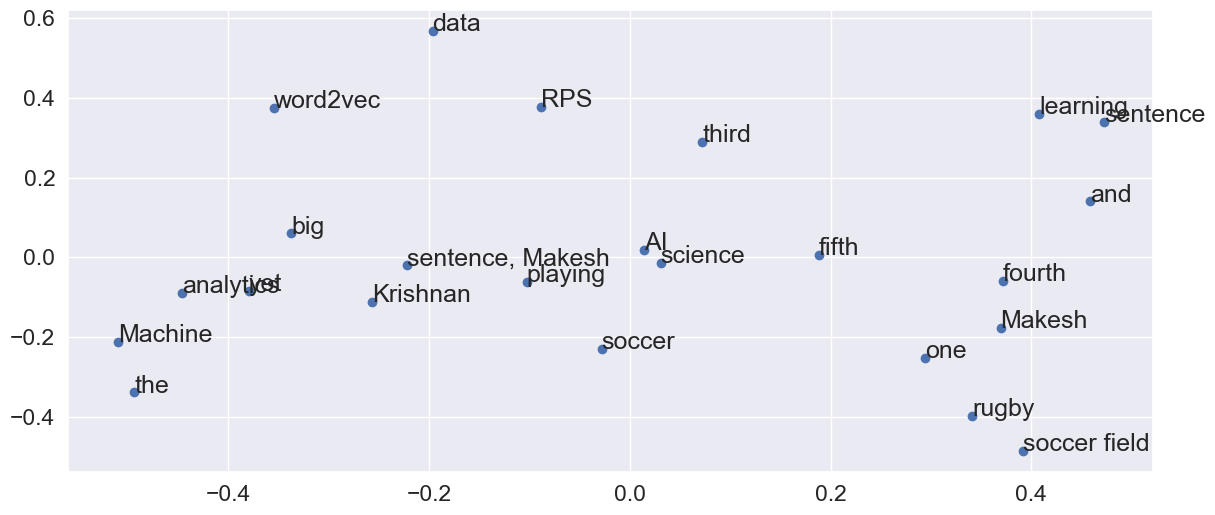

In [45]:
plt.figure(figsize=(14, 6))
plt.scatter(result[:, 0], result[:, 1])

# Get the list of words in the vocabulary
words = model.wv.index_to_key


for i, word in enumerate(words):
	pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))

#### Example 2

#### Load Google’s Word2Vec Embedding
- Training your own word vectors may be the best approach for a given NLP problem.

- But it can take a long time, a fast computer with a lot of RAM and disk space, and perhaps some expertise in finessing the input data and training algorithm.

- An alternative is to simply use an existing `pre-trained word embedding`.

- A pre-trained model is nothing more than a file containing tokens and their associated word vectors. 

- The pre-trained Google `word2vec model` was trained on `Google news data` (about 100 billion words); it contains 3 million words and phrases and was fit using 300-dimensional word vectors.

It is a 1.53 Gigabytes file. You can download it from here: GoogleNews-vectors-negative300.bin.gz https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit



In [47]:
from gensim.models import KeyedVectors

In [48]:
# load the google word2vec model
filename = r'D:\Makesh\Working\AI\RPS\Day04\Dataset\GoogleNews-vectors-negative300.bin'

In [49]:
model    = KeyedVectors.load_word2vec_format(filename, 
                                             binary= True, 
                                             limit = 100000)

In [50]:
model.vector_size

300

In [51]:
# Get the vocabulary size
vocab_size = len(model.key_to_index)

print("Vocabulary size:", vocab_size)

Vocabulary size: 100000


#### Examples

calculate: (king - man) + woman = ?

In [59]:
result = model.most_similar(positive=['woman', 'Hero'], negative=['man'], topn=10)

result

[('Heroes', 0.5069684386253357),
 ('heroine', 0.45727023482322693),
 ('Diva', 0.4514290392398834),
 ('Girl', 0.448719322681427),
 ('Honor', 0.4084346890449524),
 ('Dream', 0.3975178897380829),
 ('Heroic', 0.38666200637817383),
 ('Daughter', 0.38028237223625183),
 ('Superstar', 0.37996119260787964),
 ('Woman', 0.37596526741981506)]

In [64]:
result = model.most_similar(positive=['India', 'Riyadh'], negative=['Chennai'], topn=4)

result

[('Saudi_Arabia', 0.7290210723876953),
 ('Saudi', 0.6700404286384583),
 ('Saudis', 0.6004118323326111),
 ('Saudi_Arabian', 0.5835568308830261)]

what if the token is not in the model

In [73]:
result = model.most_similar(positive=['India', 'Dhaka'], negative=['Delhi'], topn=4)

result

[('Bangladesh', 0.7999163269996643),
 ('Chittagong', 0.6465892791748047),
 ('Sri_Lanka', 0.6379389762878418),
 ('Pakistan', 0.6231697797775269)]

In [71]:
result = model.most_similar(positive=['India', 'Karachi'], negative=['Bangalore'], topn=4)

result

[('Pakistan', 0.7550593614578247),
 ('Bangladesh', 0.6441815495491028),
 ('Balochistan', 0.6238784790039062),
 ('Lahore', 0.6214929819107056)]

#### Example 3

In [74]:
import re  # For preprocessing
import pandas as pd  # For data handling

pd.set_option('display.max_colwidth', 120)

from time import time  # To time our operations
from collections import defaultdict  # For word frequency

import spacy  # For preprocessing

import logging  # Setting up the loggings to monitor gensim
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)

This dataset contains the characters, locations, episode details, and script lines for approximately 600 Simpsons episodes, dating back to 1989. It can be found here: https://www.kaggle.com/ambarish/fun-in-text-mining-with-simpsons/data (~25MB)

In [75]:
df = pd.read_csv(r'D:\Makesh\Working\AI\RPS\Day04\Dataset\Simphsons\simpsons_script_lines.csv')
df.shape

C:\Users\reach\AppData\Local\Temp\ipykernel_31652\3723043328.py:1: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'D:\Makesh\Working\AI\RPS\Day04\Dataset\Simphsons\simpsons_script_lines.csv')


(158271, 13)

In [76]:
df.sample(5)

,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
10085,19671,66,205,Lenny Leonard: I gotta go home and change!,946000,True,165.0,10.0,Lenny Leonard,Springfield Nuclear Power Plant,I gotta go home and change!,i gotta go home and change,6
7220,16790,56,36,(Springfield Prison: int. prison - bob's cell),254000,False,NaN,451.0,NaN,Springfield Prison,NaN,NaN,NaN
32337,42152,148,85,Milhouse Van Houten: (STEPS IN BOLDLY) That job is taken.,356000,True,25.0,1433.0,Milhouse Van Houten,STREET OUTSIDE MOE'S,That job is taken.,that job is taken,4
144778,155294,557,192,C. Montgomery Burns: Hold on. This feels light. (WORRIED) One of these deeds is missing a signature.,870000,true,15,4394.0,C. Montgomery Burns,FRACKING BUILDING,Hold on. This feels light. One of these deeds is missing a signature.,hold on this feels light one of these deeds is missing a signature,13
29660,39383,137,126,"Homer Simpson: (DERISIVE) Go back to Massachusetts, pinko!",640000,True,2.0,1363.0,Homer Simpson,AIR SHOW,"Go back to Massachusetts, pinko!",go back to massachusetts pinko,5


In [77]:
df.isnull().sum()

id                        0
episode_id                0
number                    0
raw_text                  0
timestamp_in_ms           0
speaking_line             0
character_id          17521
location_id             407
raw_character_text    17522
raw_location_text       408
spoken_words          26159
normalized_text       26184
word_count            26159
dtype: int64

In [78]:
# Removing the missing values:
df = df.dropna().reset_index(drop=True)
df.isnull().sum()

id                    0
episode_id            0
number                0
raw_text              0
timestamp_in_ms       0
speaking_line         0
character_id          0
location_id           0
raw_character_text    0
raw_location_text     0
spoken_words          0
normalized_text       0
word_count            0
dtype: int64

#### Cleaning:

We are lemmatizing and removing the stopwords and non-alphabetic characters for each line of dialogue.

In [79]:
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser']) # disabling Named Entity Recognition for speed

In [80]:
def cleaning(doc):
    # Lemmatizes and removes stopwords
    # doc needs to be a spacy Doc object
    txt = [token.lemma_ for token in doc if not token.is_stop]
    
    # Word2Vec uses context words to learn the vector representation of a target word,
    # if a sentence is only one or two words long, the benefit for the training is very small
    
    if len(txt) > 2:
        return ' '.join(txt)

In [81]:
%%time

# Removes non-alphabetic characters:
brief_cleaning = (re.sub("[^A-Za-z']+", ' ', str(row)).lower() for row in df['spoken_words'])

CPU times: total: 0 ns
Wall time: 157 μs


#### Taking advantage of spaCy .pipe() 

In [82]:
%%time
## takes about 3 mins
t = time()

txt = [cleaning(doc) for doc in nlp.pipe(brief_cleaning, batch_size=5000)]

print('Time to clean up everything: {} mins'.format(round((time() - t) / 60, 2)))

Time to clean up everything: 1.03 mins
CPU times: total: 1min
Wall time: 1min 2s


In [83]:
# Put the results in a DataFrame to remove missing values and duplicates:
df_clean = pd.DataFrame({'clean': txt})
df_clean = df_clean.dropna().drop_duplicates()

df_clean.shape

(85942, 1)

In [84]:
df_clean.sample(10)

,clean
32879,um actually sir uh considerably
104078,cheat selma crazy hamburger get rancid steak home
128382,feeling someday describe psychiatrist
86125,king thief worship
32648,ooh pardon santo real bart simpson phony credit good like pant split
78683,weird start egg
17671,door door sugar marvelous idea mother talk sugar man mother big boy wish excuse
96114,marge girl hear pant be hire butt will quit
41282,slow fella get way leg bright future
107085,sit zero sheet wind


#### Bigrams:
We are using Gensim __Phrases__ package to automatically detect common phrases (bigrams) from a list of sentences.

In [85]:
from gensim.models.phrases import Phrases, Phraser

As Phrases() takes a list of list of words as input:

In [86]:
sent = [row.split() for row in df_clean['clean']]

In [87]:
phrases = Phrases(sent, min_count=30, progress_per=10000)

INFO - 22:31:57: collecting all words and their counts
INFO - 22:31:57: PROGRESS: at sentence #0, processed 0 words and 0 word types
INFO - 22:31:57: PROGRESS: at sentence #10000, processed 63712 words and 52844 word types
INFO - 22:31:57: PROGRESS: at sentence #20000, processed 131362 words and 99904 word types
INFO - 22:31:57: PROGRESS: at sentence #30000, processed 193424 words and 138397 word types
INFO - 22:31:57: PROGRESS: at sentence #40000, processed 250387 words and 172396 word types
INFO - 22:31:57: PROGRESS: at sentence #50000, processed 311825 words and 208172 word types
INFO - 22:31:57: PROGRESS: at sentence #60000, processed 374128 words and 243171 word types
INFO - 22:31:57: PROGRESS: at sentence #70000, processed 436954 words and 278034 word types
INFO - 22:31:57: PROGRESS: at sentence #80000, processed 498546 words and 311149 word types
INFO - 22:31:57: collected 330030 token types (unigram + bigrams) from a corpus of 537962 words and 85942 sentences
INFO - 22:31:57: m

Transform the corpus based on the bigrams detected:

In [88]:
sentences = phrases[sent]

#### Most Frequent Words:
Mainly a sanity check of the effectiveness of the lemmatization, removal of stopwords, and addition of bigrams.

In [89]:
word_freq = defaultdict(int)

for sent in sentences:
    for i in sent:
        word_freq[i] += 1
        
len(word_freq)

29704

In [90]:
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

['oh', 'like', 'know', 'get', 'hey', 'think', 'come', 'right', 'look', 'want']

#### Training the model
Gensim Word2Vec Implementation:

In [92]:
import multiprocessing

from gensim.models import Word2Vec

separate the training in 3 distinctive steps for clarity and monitoring.

1. Word2Vec():
In this first step, set up the parameters of the model one-by-one.
do not supply the parameter sentences, and therefore leave the model uninitialized, purposefully.

2. build_vocab():
Here it builds the vocabulary from a sequence of sentences and thus initialized the model.
With the loggings, we can follow the progress and even more important, the effect of __min_count__ and __sample__ on the word corpus. 

3. train():
Finally, trains the model.
The loggings here are mainly useful for monitoring, making sure that no threads are executed instantaneously.

In [93]:
cores = multiprocessing.cpu_count() # Count the number of cores in a computer
cores

16

#### The parameters:
- min_count = int - 

Ignores all words with total absolute frequency lower than this - (2, 100)

- window = int - 

The maximum distance between the current and predicted word within a sentence. E.g. window words on the left and window words on the left of our target - (2, 10)

- size = int - 

Dimensionality of the feature vectors. - (50, 300)

- sample = float - 

The threshold for configuring which higher-frequency words are randomly downsampled. Highly influencial. - (0, 1e-5)

- alpha = float - 

The initial learning rate - (0.01, 0.05)

- min_alpha = float - 

Learning rate will linearly drop to min_alpha as training progresses. To set it: alpha - (min_alpha * epochs) ~ 0.00

-

In [94]:
%%time
w2v_model = Word2Vec(min_count=20,
                     window=2,
                     vector_size=300,
                     sample=6e-5, 
                     alpha=0.03, 
                     min_alpha=0.0007, 
                     negative=20,
                     workers=cores-1)

INFO - 22:33:16: Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=300, alpha=0.03>', 'datetime': '2025-11-19T22:33:16.689121', 'gensim': '4.4.0', 'python': '3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26100-SP0', 'event': 'created'}


CPU times: total: 0 ns
Wall time: 896 μs


### Building the Vocabulary Table:
Word2Vec requires us to build the vocabulary table (simply digesting all the words and filtering out the unique words, and doing some basic counts on them):

In [95]:
t = time()

w2v_model.build_vocab(sentences, progress_per=10000)

print('Time to build vocab: {} mins'.format(round((time() - t) / 60, 2)))

INFO - 22:33:22: collecting all words and their counts
INFO - 22:33:22: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO - 22:33:22: PROGRESS: at sentence #10000, processed 61831 words, keeping 9525 word types
INFO - 22:33:22: PROGRESS: at sentence #20000, processed 127705 words, keeping 14401 word types
INFO - 22:33:22: PROGRESS: at sentence #30000, processed 188183 words, keeping 17439 word types
INFO - 22:33:22: PROGRESS: at sentence #40000, processed 243773 words, keeping 20123 word types
INFO - 22:33:23: PROGRESS: at sentence #50000, processed 303617 words, keeping 22580 word types
INFO - 22:33:23: PROGRESS: at sentence #60000, processed 364341 words, keeping 24839 word types
INFO - 22:33:23: PROGRESS: at sentence #70000, processed 425756 words, keeping 27000 word types
INFO - 22:33:23: PROGRESS: at sentence #80000, processed 486003 words, keeping 28832 word types
INFO - 22:33:23: collected 29704 word types from a corpus of 524297 raw words and 85942 sentence

Time to build vocab: 0.01 mins


### Training of the model:
Parameters of the training:

total_examples = int - Count of sentences;

epochs = int - Number of iterations (epochs) over the corpus - [10, 20, 30]

In [96]:
%%time
t = time()

w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)

print('Time to train the model: {} mins'.format(round((time() - t) / 60, 2)))

INFO - 22:33:32: Word2Vec lifecycle event {'msg': 'training model with 15 workers on 3328 vocabulary and 300 features, using sg=0 hs=0 sample=6e-05 negative=20 window=2 shrink_windows=True', 'datetime': '2025-11-19T22:33:32.153348', 'gensim': '4.4.0', 'python': '3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26100-SP0', 'event': 'train'}
INFO - 22:33:32: EPOCH 0: training on 524297 raw words (199313 effective words) took 0.7s, 272373 effective words/s
INFO - 22:33:33: EPOCH 1: training on 524297 raw words (199186 effective words) took 0.7s, 281364 effective words/s
INFO - 22:33:34: EPOCH 2: training on 524297 raw words (199669 effective words) took 0.8s, 239390 effective words/s
INFO - 22:33:35: EPOCH 3: training on 524297 raw words (199673 effective words) took 0.7s, 277717 effective words/s
INFO - 22:33:35: EPOCH 4: training on 524297 raw words (199703 effective words) took 0.7s, 282533 effective words/s


Time to train the model: 0.38 mins
CPU times: total: 46.8 s
Wall time: 22.8 s


In [97]:
# calling init_sims(), which will make the model much more memory-efficient:

w2v_model.init_sims(replace=True)

C:\Users\reach\AppData\Local\Temp\ipykernel_31652\1624602193.py:3: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  w2v_model.init_sims(replace=True)
WARNING - 22:34:01: destructive init_sims(replace=True) deprecated & no longer required for space-efficiency


#### Exploring the model
Most similar to:
Here, we will ask our model to find the word most similar to some of the most iconic characters of the Simpsons!

In [98]:
w2v_model.wv.most_similar(positive=["jack"])

[('frost', 0.6445698738098145),
 ('captain', 0.6400986313819885),
 ('airline', 0.6132258176803589),
 ('crystal', 0.6022113561630249),
 ('delightful', 0.6003594398498535),
 ('cracker', 0.6000039577484131),
 ('product', 0.599799394607544),
 ('box', 0.5986826419830322),
 ('price', 0.59804767370224),
 ('avenue', 0.5872803926467896)]

In [99]:
w2v_model.wv.most_similar(positive=["homer_simpson"])

[('congratulation', 0.6933950781822205),
 ('pleased', 0.6845136880874634),
 ('governor', 0.6818351149559021),
 ('recent', 0.6742685437202454),
 ('elect', 0.6740196943283081),
 ('waylon', 0.6737107038497925),
 ('easily', 0.6634707450866699),
 ('select', 0.6617774963378906),
 ('fellow', 0.6569489240646362),
 ('united_states', 0.6523934006690979)]

## Similarities:
Here, we will see how similar are two words to each other :

In [100]:
w2v_model.wv.similarity("homer", 'tavern')

np.float32(0.38908735)

In [ ]:
w2v_model.wv.similarity('maggie', 'baby')

## Odd-One-Out:
Here, we ask our model to give us the word that does not belong to the list!

Between Jimbo, Milhouse, and Kearney, who is the one who is not a bully?

In [101]:
w2v_model.wv.doesnt_match(['jimbo', 'milhouse', 'kearney'])

WARNING - 22:34:29: vectors for words {'kearney'} are not present in the model, ignoring these words


'jimbo'

In [102]:
w2v_model.wv.doesnt_match(["nelson", "bart", "milhouse"])

'nelson'

In [103]:
# how is the relationship between Homer and his two sister-in-laws?

w2v_model.wv.doesnt_match(['homer', 'patty', 'selma'])

'homer'

In [104]:
w2v_model.wv.most_similar(positive=["bart"])

[('lisa', 0.7553948163986206),
 ('hearing', 0.7326637506484985),
 ('substitute', 0.7300471067428589),
 ('convince', 0.7052587270736694),
 ('discipline', 0.6869102716445923),
 ('mom_dad', 0.6839169263839722),
 ('janey', 0.6779362559318542),
 ('childhood', 0.6739891767501831),
 ('surprised', 0.6738200783729553),
 ('homework', 0.6670300960540771)]

## Analogy difference:

Which word is to woman as homer is to marge?

In [105]:
w2v_model.wv.most_similar(positive=["woman", "homer"], negative=["marge"], topn=3)

[('reason', 0.5533895492553711),
 ('adopt', 0.5459734201431274),
 ('ought', 0.5404617786407471)]

"man" comes at the first position, that looks about right!

Which word is to woman as bart is to man?

In [106]:
w2v_model.wv.most_similar(positive=["woman", "bart"], negative=["man"], topn=3)

[('lisa', 0.6535056829452515),
 ('parent', 0.6472522616386414),
 ('substitute', 0.6037383079528809)]